

Use FEM to solve the next EDO. Compare with the analytical solution for some N elements.


Build a general script to solve a PDE of order two with Dirichlet's conditions: $y(a)$, $y(b)$, $x \in [a, b]$.


Nota: Solving the Green's function for this particular case we are able to find the analytical solution:

$
\frac{d^2 y}{dx^2} = -xe^x, \quad y(0) = (3 - e), \quad y(1) = 0$


$
y(x) = 1 - e - e^x(2 - x) - x$




In [4]:
%%writefile FEM.py
import numpy as np

def FEM(N, f, xa, xb, ya, yb):
    """
    Rutina para resolver d2y/dx2 = f(x)
    con condiciones de Dirichlet y(xa)=ya, y(xb)=yb
    """
    num_nodos = N + 1
    x = np.linspace(xa, xb, num_nodos)
    h = (xb - xa) / N

    K = np.zeros((num_nodos, num_nodos))
    F = np.zeros(num_nodos)

    # Matriz de rigidez local para la segunda derivada
    k_local = (1.0 / h) * np.array([[1, -1], [-1, 1]])

    for i in range(N):
        idx = [i, i + 1]
        K[np.ix_(idx, idx)] += k_local

        # Lado derecho (ajustado para d2y/dx2 = f)
        F[i]   -= f(x[i]) * h / 2
        F[i+1] -= f(x[i+1]) * h / 2

    # Aplicar Dirichlet
    F_interno = F[1:-1] - K[1:-1, 0] * ya - K[1:-1, -1] * yb
    K_interno = K[1:-1, 1:-1]

    u_interno = np.linalg.solve(K_interno, F_interno)

    y_sol = np.zeros(num_nodos)
    y_sol[0], y_sol[-1] = ya, yb
    y_sol[1:-1] = u_interno

    return x, y_sol

Writing FEM.py


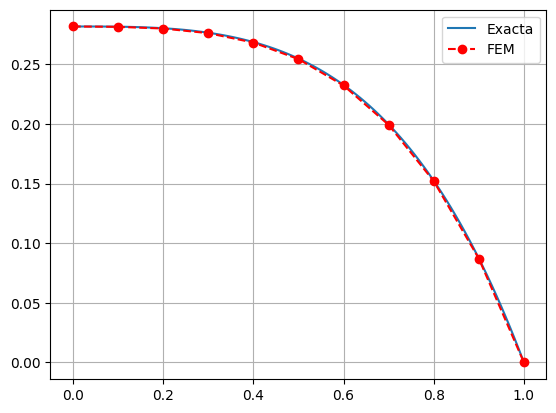

In [5]:
import matplotlib.pyplot as plt
from FEM import *

def exact(x):
    return 1 - np.exp(1) + (np.exp(x) * (2 - x)) - x

def f(x):
    return -x * np.exp(x)

# Resolver
xa, xb = 0, 1
ya, yb = 3 - np.exp(1), 0
N = 10

x_fem, y_fem = FEM(N, f, xa, xb, ya, yb)

# Graficar
x_aux = np.linspace(xa, xb, 100)
plt.plot(x_aux, exact(x_aux), label='Exacta')
plt.plot(x_fem, y_fem, 'ro--', label='FEM')
plt.legend()
plt.grid(True)
plt.show()

# Exercise 2: Solve the EDO:

see pag 36: https://cimec.org.ar/foswiki/pub/Main/Cimec/CursoFEM/cursofem_1.pdf

$$-\frac{d^2U}{dx^2}(x) = \sin(\pi x), \quad \text{in } 0 \leq x \leq 1, \quad \text{with } U(0) = U(1) = 0.$$

The exact solution is known:
$$U(x) = \frac{1}{\pi^2}\sin(\pi x)$$

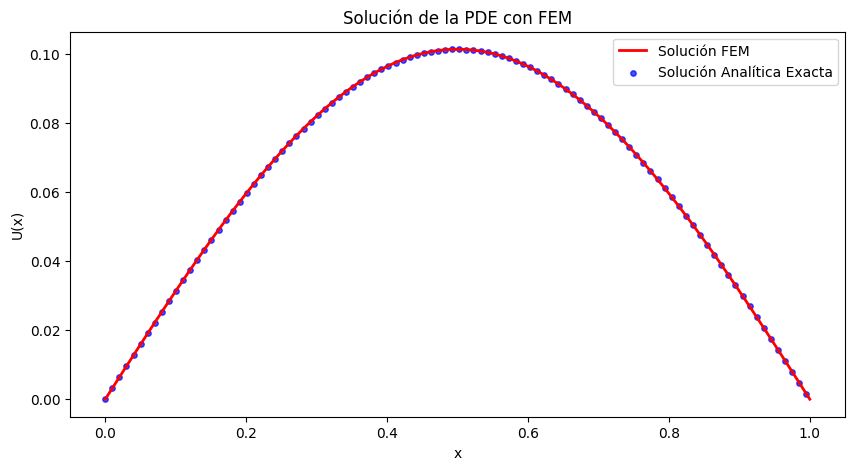

Error máximo absoluto entre soluciones: 2.44e-06


In [7]:
from FEM import FEM

# 2. parámetros según el enunciado del problema
N = 100
xa, xb = 0.0, 1.0   # Dominio: 0 <= x <= 1
ya, yb = 0.0, 0.0   # Condiciones de frontera: U(0) = U(1) = 0

f_problema = lambda x: -np.sin(np.pi * x)

x_values, u_values = FEM(N, f_problema, xa, xb, ya, yb)

# 4. Solución analítica exacta para comprobar la precisión
x_exact = np.linspace(xa, xb, 200)
u_exact = (1.0 / (np.pi**2)) * np.sin(np.pi * x_exact)

# 5. Graficar resultados (Siguiendo el estilo visual deseado)
plt.figure(figsize=(10, 5))
plt.plot(x_values, u_values, label='Solución FEM', c="red", linewidth=2)
plt.scatter(x_exact[::2], u_exact[::2], label='Solución Analítica Exacta', color="blue", s=15, alpha=0.7)

plt.title('Solución de la PDE con FEM')
plt.xlabel('x')
plt.ylabel('U(x)')
plt.legend()
plt.show()

# Validar error máximo
error_max = np.max(np.abs(np.interp(x_exact, x_values, u_values) - u_exact))
print(f"Error máximo absoluto entre soluciones: {error_max:.2e}")